In [71]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression


In [72]:
df = pd.read_csv("HousePricePrediction.csv")

df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'LotConfig', 'BldgType',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'Exterior1st', 'BsmtFinSF2',
       'TotalBsmtSF', 'SalePrice'],
      dtype='str')

In [73]:
df.drop(["Id"], axis=1, inplace=True )

In [74]:
for i in df.columns:
    print(i,":", df[i].unique(), "\n")

MSSubClass : [ 60  20  70  50 190  45  90 120  30  85  80 160  75 180  40 150] 

MSZoning : <ArrowStringArray>
['RL', 'RM', 'C (all)', 'FV', 'RH', nan]
Length: 6, dtype: str 

LotArea : [ 8450  9600 11250 ...  1894 20000 10441] 

LotConfig : <ArrowStringArray>
['Inside', 'FR2', 'Corner', 'CulDSac', 'FR3']
Length: 5, dtype: str 

BldgType : <ArrowStringArray>
['1Fam', '2fmCon', 'Duplex', 'TwnhsE', 'Twnhs']
Length: 5, dtype: str 

OverallCond : [5 8 6 7 4 2 3 9 1] 

YearBuilt : [2003 1976 2001 1915 2000 1993 2004 1973 1931 1939 1965 2005 1962 2006
 1960 1929 1970 1967 1958 1930 2002 1968 2007 1951 1957 1927 1920 1966
 1959 1994 1954 1953 1955 1983 1975 1997 1934 1963 1981 1964 1999 1972
 1921 1945 1982 1998 1956 1948 1910 1995 1991 2009 1950 1961 1977 1985
 1979 1885 1919 1990 1969 1935 1988 1971 1952 1936 1923 1924 1984 1926
 1940 1941 1987 1986 2008 1908 1892 1916 1932 1918 1912 1947 1925 1900
 1980 1989 1992 1949 1880 1928 1978 1922 1996 2010 1946 1913 1937 1942
 1938 1974 1893 1914 1

In [75]:
df.isnull().sum()

MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

In [76]:
df.duplicated().sum()

8

In [77]:
df = df.drop_duplicates()

In [78]:
df.info()

<class 'pandas.DataFrame'>
Index: 2911 entries, 0 to 2918
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MSSubClass    2911 non-null   int64  
 1   MSZoning      2907 non-null   str    
 2   LotArea       2911 non-null   int64  
 3   LotConfig     2911 non-null   str    
 4   BldgType      2911 non-null   str    
 5   OverallCond   2911 non-null   int64  
 6   YearBuilt     2911 non-null   int64  
 7   YearRemodAdd  2911 non-null   int64  
 8   Exterior1st   2910 non-null   str    
 9   BsmtFinSF2    2910 non-null   float64
 10  TotalBsmtSF   2910 non-null   float64
 11  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(5), str(4)
memory usage: 351.9 KB


In [79]:
df.select_dtypes(include=["string"]).nunique()

MSZoning        5
LotConfig       5
BldgType        5
Exterior1st    15
dtype: int64

# Imputer as Mean

In [80]:
df1 = df.copy()
df1["SalePrice"] = mean_imp.fit_transform(df1[["SalePrice"]])
mean_imp = SimpleImputer(strategy="mean")


In [81]:
ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)

cols = df1.select_dtypes(include=["string"])

cols_encoded = ohe.fit_transform(cols)

# Convert back to DataFrame with feature names
df_ohe = pd.DataFrame(cols_encoded, columns=ohe.get_feature_names_out(cols.columns))
df1 = pd.concat([df1, df_ohe], axis=1)

df1 = df1.drop(cols.columns, axis=1)
df1 = df1.dropna()

X = df1.drop("SalePrice", axis=1)
y = df1["SalePrice"]


# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# test train split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y , test_size=0.3, random_state=42
)

model1 = LinearRegression()
model1.fit(X_train, y_train)
y_pred = model1.predict(X_test)

print(f"r2 score: {r2_score(y_test, y_pred)}")
print(f"mae: {mean_absolute_error(y_test, y_pred)}")
print(f"mse: {mean_squared_error(y_test, y_pred)}")
print(f"rmse: {root_mean_squared_error(y_test, y_pred)}")
print("mean abs percentage error: ",mean_absolute_percentage_error(y_test, y_pred))

r2 score: 0.2905362265541179
mae: 34152.608322212516
mse: 2553741881.3853283
rmse: 50534.56125648395
mean abs percentage error:  0.20943013366914126


# Imputer as Mode

In [82]:
df2 = df.copy()
df2["SalePrice"] = mode_imp.fit_transform(df2[["SalePrice"]])
mode_imp = SimpleImputer(strategy="most_frequent")

In [83]:
ohe = OneHotEncoder(drop="first", handle_unknown="ignore",sparse_output=False)

cols = df2.select_dtypes(include=["string"])

cols_encoded = ohe.fit_transform(cols)

# Convert back to DataFrame with feature names
df_ohe = pd.DataFrame(cols_encoded, columns=ohe.get_feature_names_out(cols.columns))
df2 = pd.concat([df2, df_ohe], axis=1)

df2 = df2.drop(cols.columns, axis=1)
df2 = df2.dropna()

X = df2.drop("SalePrice", axis=1)
y = df2["SalePrice"]


# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# test train split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y , test_size=0.3, random_state=42
)

model2 = LinearRegression()
model2.fit(X_train, y_train)
y_pred = model2.predict(X_test)


print(f"r2 score: {r2_score(y_test, y_pred)}")
print(f"mae: {mean_absolute_error(y_test, y_pred)}")
print(f"mse: {mean_squared_error(y_test, y_pred)}")
print(f"rmse: {root_mean_squared_error(y_test, y_pred)}")
print("mean abs percentage error: ",mean_absolute_percentage_error(y_test, y_pred))

r2 score: 0.255881349213681
mae: 36181.80369166517
mse: 2996979900.9557605
rmse: 54744.67920223627
mean abs percentage error:  0.22207424500584297


# droppping all missing target values

In [84]:
df3 = df.copy()

#encoder
ohe = OneHotEncoder(drop="first", handle_unknown="ignore",sparse_output=False)

cols = df3.select_dtypes(include=["string"])

cols_encoded = ohe.fit_transform(cols)

# Convert back to DataFrame with feature names
df_ohe = pd.DataFrame(cols_encoded, columns=ohe.get_feature_names_out(cols.columns))
df3 = pd.concat([df3, df_ohe], axis=1)

df3 = df3.drop(cols.columns, axis=1)
df3 = df3.dropna()

X = df3.drop("SalePrice", axis=1)
y = df3["SalePrice"]

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# test train split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y , test_size=0.3, random_state=42
)


model3 = LinearRegression()
model3.fit(X_train, y_train)
y_pred = model3.predict(X_test)


print(f"r2 score: {r2_score(y_test, y_pred)}")
print(f"mae: {mean_absolute_error(y_test, y_pred)}")
print(f"mse: {mean_squared_error(y_test, y_pred)}")
print(f"rmse: {root_mean_squared_error(y_test, y_pred)}")
print("mean abs percentage error: ",mean_absolute_percentage_error(y_test, y_pred))

r2 score: 0.6294462899245681
mae: 33518.98464395498
mse: 2585758532.370284
rmse: 50850.35429935846
mean abs percentage error:  0.19174612570561378


In [85]:
import pandas as pd

# Get coefficients with feature names
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model3.coef_
}).sort_values(by="Coefficient", ascending=False)

print(coef_df.head(10))   # Top 10 positive contributors
print(coef_df.tail(10))   # Top 10 negative contributors


                Feature   Coefficient
0            MSSubClass  36468.287716
6           TotalBsmtSF  34640.118927
3             YearBuilt  22577.411869
4          YearRemodAdd  15477.979221
9           MSZoning_RL  12380.957626
22  Exterior1st_BrkFace   7196.065201
10          MSZoning_RM   6922.396895
7           MSZoning_FV   6832.636473
1               LotArea   6188.611809
2           OverallCond   4515.507780
                Feature   Coefficient
27  Exterior1st_MetalSd   -787.537574
13        LotConfig_FR2  -1369.418284
31  Exterior1st_VinylSd  -2575.057902
5            BsmtFinSF2  -2714.469801
28  Exterior1st_Plywood  -3199.943040
25  Exterior1st_HdBoard  -6714.161817
17      BldgType_Duplex -13661.177798
16      BldgType_2fmCon -16908.194659
18       BldgType_Twnhs -21916.253911
19      BldgType_TwnhsE -28487.008983


In [86]:
a = ["TotalBsmtSF","MSSubClass","BldgType_TwnhsE","YearBuilt","BldgType_Twnhs",
     "YearRemodAdd","BldgType_2fmCon","MSZoning_RL","BldgType_Duplex","LotArea",
     "MSZoning_FV","Exterior1st_CemntBd","MSZoning_RM","Exterior1st_HdBoard", "BsmtFinSF2","SalePrice"]


In [87]:
result = permutation_importance(model1, X_test, y_test, n_repeats=10, random_state=42)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(15))


                Feature  Importance
6           TotalBsmtSF    0.212384
3             YearBuilt    0.093022
4          YearRemodAdd    0.073115
1               LotArea    0.031111
24  Exterior1st_CemntBd    0.016404
10          MSZoning_RM    0.015913
31  Exterior1st_VinylSd    0.014108
19      BldgType_TwnhsE    0.010663
18       BldgType_Twnhs    0.008970
17      BldgType_Duplex    0.008798
12    LotConfig_CulDSac    0.005157
16      BldgType_2fmCon    0.004970
0            MSSubClass    0.004242
5            BsmtFinSF2    0.002710
29    Exterior1st_Stone    0.002233


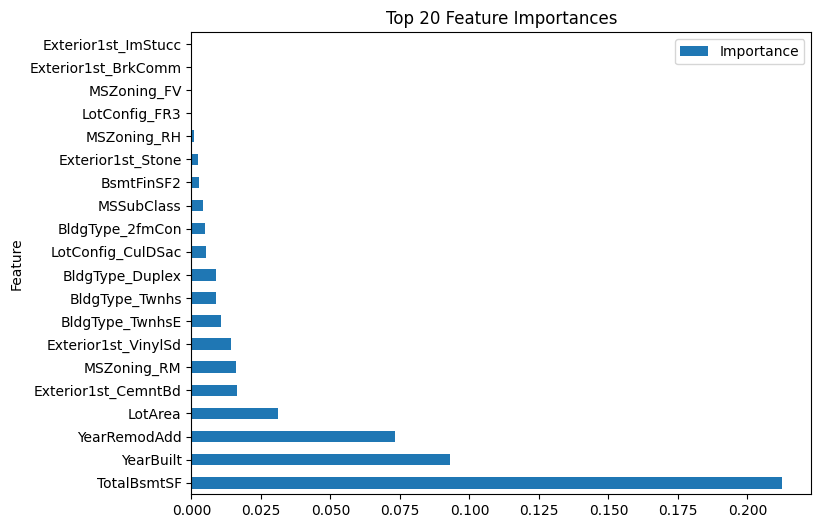

In [88]:
import matplotlib.pyplot as plt

importance_df.head(15).plot(kind="barh", x="Feature", y="Importance", figsize=(8,6))
plt.title("Top 20 Feature Importances")
plt.show()

In [89]:
result = permutation_importance(model2, X_test, y_test, n_repeats=10, random_state=42)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(15))


                Feature  Importance
6           TotalBsmtSF    0.219741
3             YearBuilt    0.082986
4          YearRemodAdd    0.075013
1               LotArea    0.035229
24  Exterior1st_CemntBd    0.017828
31  Exterior1st_VinylSd    0.014890
19      BldgType_TwnhsE    0.010764
17      BldgType_Duplex    0.008635
18       BldgType_Twnhs    0.008536
16      BldgType_2fmCon    0.005394
0            MSSubClass    0.005137
12    LotConfig_CulDSac    0.004755
9           MSZoning_RL    0.003971
5            BsmtFinSF2    0.003668
7           MSZoning_FV    0.002916


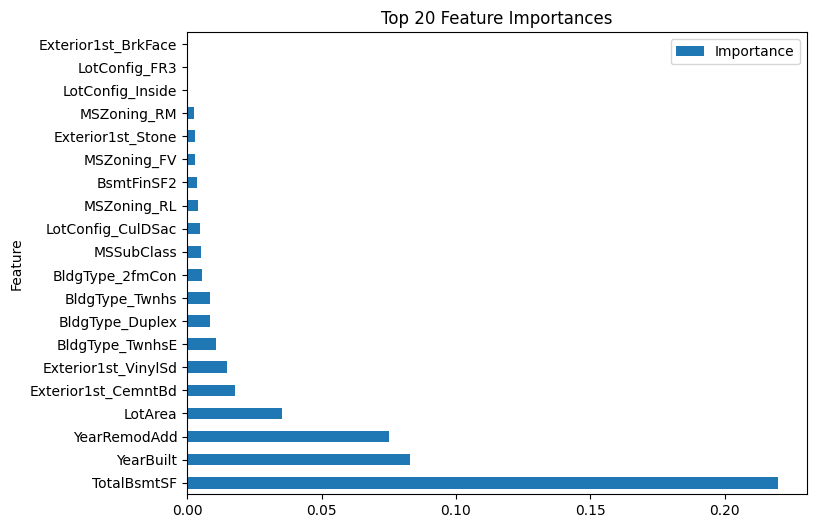

In [90]:
import matplotlib.pyplot as plt

importance_df.head(15).plot(kind="barh", x="Feature", y="Importance", figsize=(8,6))
plt.title("Top 20 Feature Importances")
plt.show()

In [91]:

from sklearn.inspection import permutation_importance

result = permutation_importance(model3, X_test, y_test, n_repeats=10, random_state=42)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(15))




                Feature  Importance
6           TotalBsmtSF    0.430108
0            MSSubClass    0.334836
19      BldgType_TwnhsE    0.229325
3             YearBuilt    0.182571
18       BldgType_Twnhs    0.143010
4          YearRemodAdd    0.089206
16      BldgType_2fmCon    0.077053
9           MSZoning_RL    0.058856
17      BldgType_Duplex    0.043205
1               LotArea    0.015736
7           MSZoning_FV    0.011713
24  Exterior1st_CemntBd    0.008195
10          MSZoning_RM    0.007351
25  Exterior1st_HdBoard    0.005745
5            BsmtFinSF2    0.004227


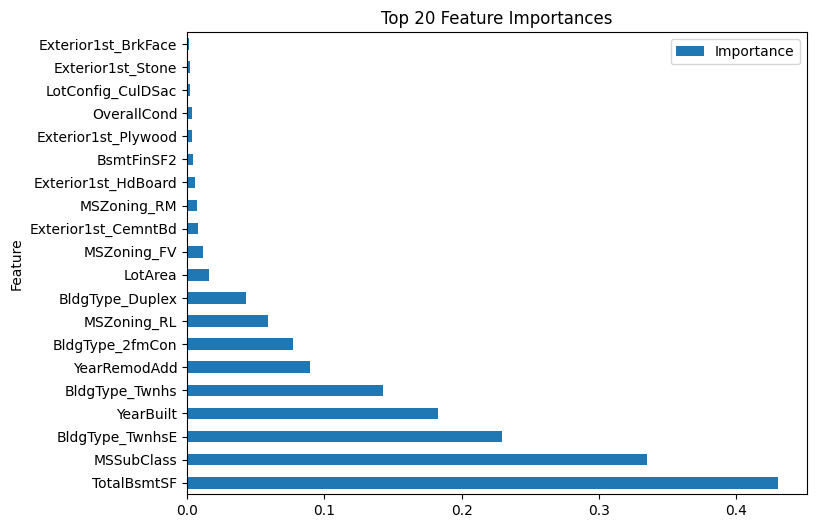

In [92]:
import matplotlib.pyplot as plt

importance_df.head(15).plot(kind="barh", x="Feature", y="Importance", figsize=(8,6))
plt.title("Top 20 Feature Importances")
plt.show()